In [1]:
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial.distance import pdist, squareform

In [2]:
with open("../debug_log.pkl", "rb") as file:
    data = pickle.load(file)
df = pd.DataFrame(data).pivot(index="step", columns="param", values="value")

FileNotFoundError: [Errno 2] No such file or directory: '../debug_log.pkl'

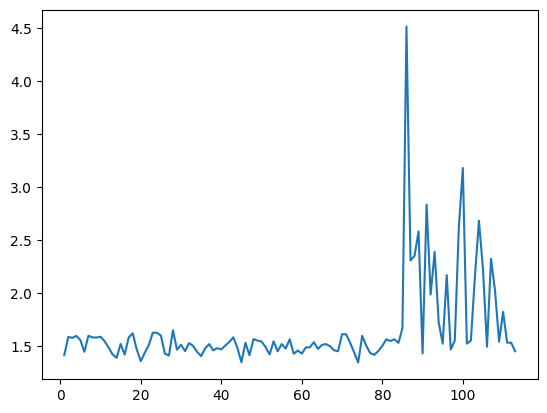

In [44]:
plt.plot(df['loss'])

In [45]:

r = df.iloc[0]
r

param
L                                                              1.473416
cone_distances        [[0.0, 0.5947475, 0.5293006, 0.65395325, 1.601...
distances1            [0.5947475, 0.5293006, 0.65395325, 1.6012449, ...
distances2            [0.5344594, 0.61737907, 0.4370085, 0.3674368, ...
latent                [[0.078521304, 0.14580083], [-0.05497213, 0.11...
loss                                                           1.418082
match_edges                                                        None
mode                                                               cone
pairs                 ([[1, 56], [2, 56], [3, 56], [4, 56], [5, 56],...
selected_distances    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
with_cycles                                                        True
x                     [[0.8556603, 0.27615616, 0.037344657, 0.224995...
Name: 1, dtype: object

(array([ 5.4648433,  5.4159966,  5.669674 ,  5.476477 , 13.187909 ,
        13.228666 ,  5.623792 ,  5.9423995, 13.032966 , 13.115395 ,
        13.125831 , 13.212718 ,  5.681441 , 13.129124 ,  5.259103 ,
         6.0654864, 13.163762 , 12.976625 , 13.209344 , 13.157644 ,
         5.229614 , 12.757037 ,  5.8335395, 13.123945 , 13.125059 ,
        13.253874 , 13.1082945,  4.845336 ], dtype=float32),
 array([0.16560036, 0.12978102, 0.13668618, 0.1216422 , 0.08565342,
        0.11482315, 0.16388127, 0.15207429, 0.12676996, 0.2623042 ,
        0.11993422, 0.14989345, 0.12731715, 0.30023435, 0.1633942 ,
        0.16944547, 0.16934793, 0.20662683, 0.33968428, 0.10390254,
        0.15233038, 0.14618605, 0.07660645, 0.26765707, 0.2858769 ,
        0.257052  , 0.1982253 , 0.14159285], dtype=float32))

In [42]:
np.nanmax(r["selected_distances"])

1.7249696

In [6]:
print(r["x"].shape, r["latent"].shape)

(28, 101) (28, 2)


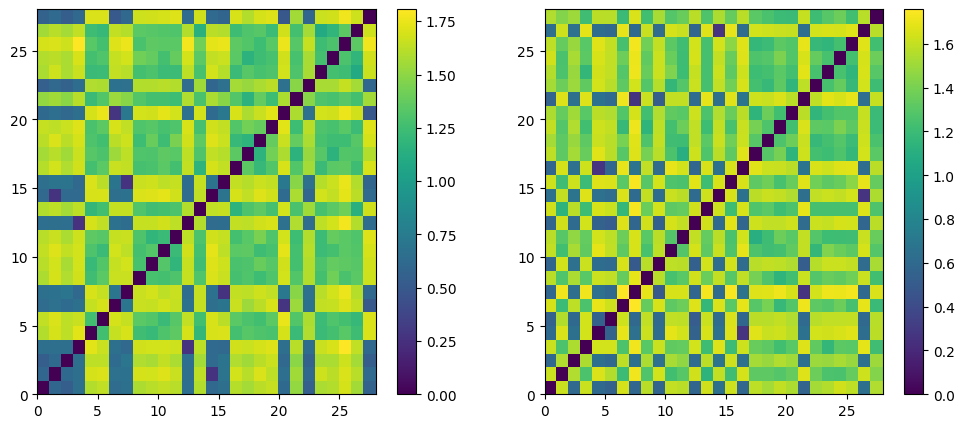

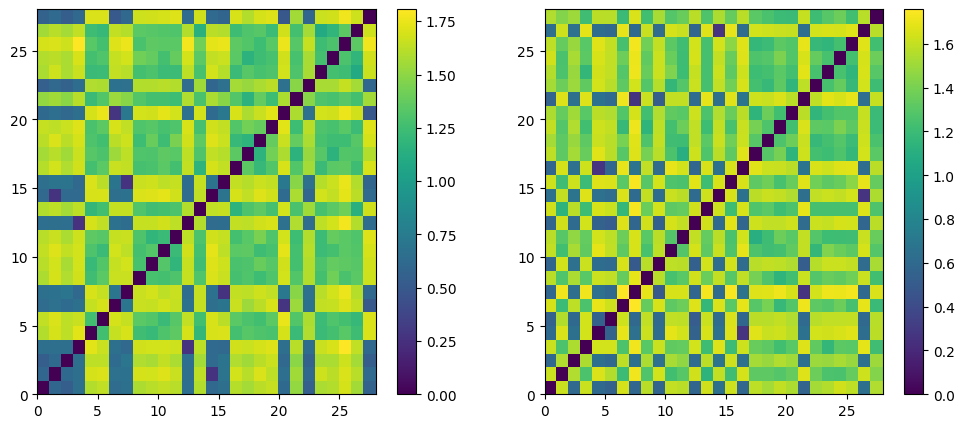

nans: 0
nans: 0


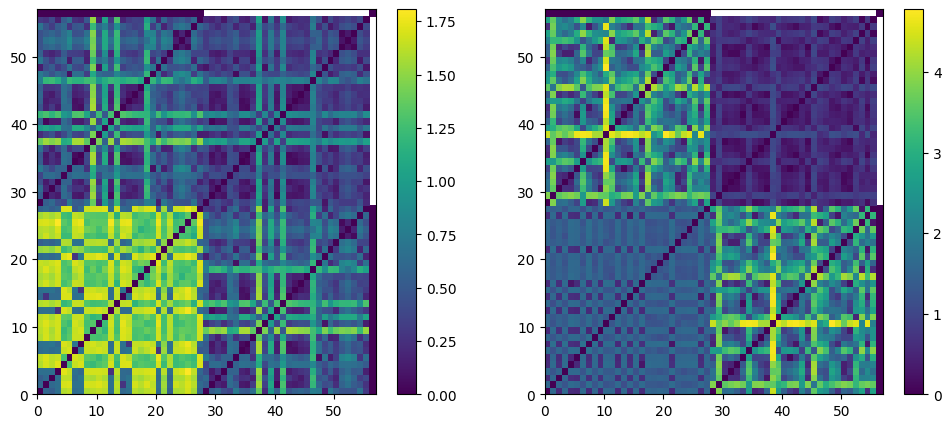

row 0: 1540 zeros in selected distances
row 0: 28 nans in selected distances
row 0: 28 positives in selected distances
9.871996 0.17266156
row 112: 1538 zeros in selected distances
row 112: 28 nans in selected distances
row 112: 30 positives in selected distances
10.12081 0.45122987


In [ ]:
rows = [0, len(df)-2]
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for i,j in enumerate(rows):
    r = df.iloc[j]
    im = axs[i].pcolor(squareform(r["distances1"]))
    # colorbar
    fig.colorbar(im, ax=axs[i])
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for i,j in enumerate(rows):
    r = df.iloc[j]
    im = axs[i].pcolor(squareform(r["distances1"]))
    fig.colorbar(im, ax=axs[i])
plt.show()
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for i,j in enumerate(rows):
    r = df.iloc[j]
    im = axs[i].pcolor(r["cone_distances"])
    fig.colorbar(im, ax=axs[i])
    # prin count nans
    print("nans:", np.sum(np.isnan(r["cone_distances"]))) 
plt.show()

for i,j in enumerate(rows):
    r = df.iloc[j]
    v = sum(r["selected_distances"]==0)
    print(f"row {j}: {v} zeros in selected distances")
    v = sum(np.isnan(r["selected_distances"]))
    print(f"row {j}: {v} nans in selected distances")
    v = sum(r["selected_distances"]>0)
    print(f"row {j}: {v} positives in selected distances")

    x = r["x"]
    y = r["latent"]
    print(np.linalg.norm(x, axis=1).mean(), np.linalg.norm(y, axis=1).mean())
